In [1]:
import os
import json
import warnings
import joblib
import numpy as np
import pandas as pd
import awkward as ak
import dask_awkward as dak
from dask.diagnostics import ProgressBar

import uproot
import zfit
from zfit.loss import UnbinnedNLL
from zfit.minimize import Minuit
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import mplhep as hep

import xgboost as xgb
from xgboost import XGBClassifier

from sklearn.metrics import (
    roc_curve, 
    auc, 
    precision_recall_curve, 
    average_precision_score, 
    confusion_matrix,
    ConfusionMatrixDisplay, 
    classification_report, 
    accuracy_score, 
    f1_score
)

/cvmfs/sft.cern.ch/lcg/views/LCG_109_cuda/x86_64-el9-gcc13-opt/lib/python3.13/site-packages/zfit/__init__.py:93: UserWarning: TensorFlow warnings are by default suppressed by zfit. In order to show them, set the environment variable ZFIT_DISABLE_TF_WARNINGS=0. In order to suppress the TensorFlow warnings AND this warning, set ZFIT_DISABLE_TF_WARNINGS=1.
  warnings.warn(


In [2]:
plt.style.use(hep.style.CMS)

In [3]:
tree_path = "Events"
mc_files_EE = {f: tree_path for f in [
    "/eos/user/t/tdeandra/skim_outputs/Merged_Eras/Merged_mc_signal_2022EE.root"
]}
mc_files = {f: tree_path for f in [
    "/eos/user/t/tdeandra/skim_outputs/Merged_Eras/Merged_mc_signal_2022.root"
]}

data_files_EE = {f: tree_path for f in [
    "/eos/user/t/tdeandra/skim_outputs/Merged_Eras/Merged_dados_Run2022E.root",
    "/eos/user/t/tdeandra/skim_outputs/Merged_Eras/Merged_dados_Run2022F.root",
    "/eos/user/t/tdeandra/skim_outputs/Merged_Eras/Merged_dados_Run2022G.root"
]}

data_files = {f: tree_path for f in [
    "/eos/user/t/tdeandra/skim_outputs/Merged_Eras/Merged_dados_Run2022C.root",
    "/eos/user/t/tdeandra/skim_outputs/Merged_Eras/Merged_dados_Run2022D.root",
]}

In [4]:
def get_b0_truth_mask(df):
    # --- 1. Constantes PDG ---
    PDG_B0        = 511
    PDG_KSTAR     = 313
    PDG_KAON_plus = 321
    PDG_PION_neg  = -211
    PDG_MUON_plus = -13
    PDG_MUON_neg  = 13
    PDG_PHOTON    = 22

    mu1_idx  = df["BPH_1Muon_genPartIdx"]
    mu2_idx  = df["BPH_2Muon_genPartIdx"]
    trk1_idx = df["Trk1_genPartIdx"]
    trk2_idx = df["Trk2_genPartIdx"]

    # Verificação de Identidade (PDG ID)
    mu1_pdg  = df["BPHGenPart_pdgId"][dak.mask(mu1_idx, mu1_idx >= 0)]
    mu2_pdg  = df["BPHGenPart_pdgId"][dak.mask(mu2_idx, mu2_idx >= 0)]
    trk1_pdg = df["BPHGenPart_pdgId"][dak.mask(trk1_idx, trk1_idx >= 0)]
    trk2_pdg = df["BPHGenPart_pdgId"][dak.mask(trk2_idx, trk2_idx >= 0)]

    flavor_match = (trk1_pdg == PDG_KAON_plus) & (trk2_pdg == PDG_PION_neg) & \
                   (mu1_pdg == PDG_MUON_plus) & (mu2_pdg == PDG_MUON_neg)

    # Linhagem do Hadron (K, Pi -> K* -> B0)
    mom_trk1_idx = df["BPHGenPart_genPartIdxMother"][dak.mask(trk1_idx, trk1_idx >= 0)]
    mom_trk2_idx = df["BPHGenPart_genPartIdxMother"][dak.mask(trk2_idx, trk2_idx >= 0)]
    
    mom_trk1_pdg = df["BPHGenPart_pdgId"][dak.mask(mom_trk1_idx, mom_trk1_idx >= 0)]
    mom_trk2_pdg = df["BPHGenPart_pdgId"][dak.mask(mom_trk2_idx, mom_trk2_idx >= 0)]
    
    # K e Pi devem vir do mesmo objeto K*0 
    match_kstar = (mom_trk1_idx == mom_trk2_idx) & (mom_trk1_idx >= 0) & \
                  (mom_trk1_pdg == PDG_KSTAR) & (mom_trk2_pdg == PDG_KSTAR)
    
    # O K*0 deve vir de um B0 (Verificando para ambos os traços)
    gmom_trk1_idx = df["BPHGenPart_genPartIdxMother"][dak.mask(mom_trk1_idx, mom_trk1_idx >= 0)]
    gmom_trk2_idx = df["BPHGenPart_genPartIdxMother"][dak.mask(mom_trk2_idx, mom_trk2_idx >= 0)]
    
    gmom_trk1_pdg = df["BPHGenPart_pdgId"][dak.mask(gmom_trk1_idx, gmom_trk1_idx >= 0)]
    gmom_trk2_pdg = df["BPHGenPart_pdgId"][dak.mask(gmom_trk2_idx, gmom_trk2_idx >= 0)]
    
    match_kstar_to_b0 = (gmom_trk1_idx == gmom_trk2_idx) & (gmom_trk1_idx >= 0) & \
                        (gmom_trk1_pdg == PDG_B0) & (gmom_trk2_pdg == PDG_B0)

    mom_mu1_idx = df["BPHGenPart_genPartIdxMother"][dak.mask(mu1_idx, mu1_idx >= 0)]
    mom_mu2_idx = df["BPHGenPart_genPartIdxMother"][dak.mask(mu2_idx, mu2_idx >= 0)]
    mom_mu1_pdg = df["BPHGenPart_pdgId"][dak.mask(mom_mu1_idx, mom_mu1_idx >= 0)]
    mom_mu2_pdg = df["BPHGenPart_pdgId"][dak.mask(mom_mu2_idx, mom_mu2_idx >= 0)]
    
    gmom_mu1_idx = df["BPHGenPart_genPartIdxMother"][dak.mask(mom_mu1_idx, mom_mu1_idx >= 0)]
    gmom_mu2_idx = df["BPHGenPart_genPartIdxMother"][dak.mask(mom_mu2_idx, mom_mu2_idx >= 0)]

    # Muon 1: Mãe é o B0 do hadron OU (Mãe é fóton e Avô é o B0 do hadron)
    mu1_from_same_b0 = (mom_mu1_idx == gmom_trk1_idx) | \
                       ((mom_mu1_pdg == PDG_PHOTON) & (gmom_mu1_idx == gmom_trk1_idx))

    mu2_from_same_b0 = (mom_mu2_idx == gmom_trk1_idx) | \
                       ((mom_mu2_pdg == PDG_PHOTON) & (gmom_mu2_idx == gmom_trk1_idx))

    # --- Máscara Final ---
    full_mask = flavor_match & match_kstar & match_kstar_to_b0 & \
                mu1_from_same_b0 & mu2_from_same_b0
    
    return ak.fill_none(full_mask, False)

In [5]:
def add_derived_columns(df):
    df["BToTrkTrkMuMu_l_xy_sig"] = df['BToTrkTrkMuMu_l_xy'] / df['BToTrkTrkMuMu_l_xy_unc']
    df["BToTrkTrkMuMu_dca_sig"]  = df['BToTrkTrkMuMu_dca'] / df['BToTrkTrkMuMu_dcaErr']
    df["BToTrkTrkMuMu_trk1_dca_sig"] = df['BToTrkTrkMuMu_trk1_dca'] / df['BToTrkTrkMuMu_trk1_dcaErr']
    df["BToTrkTrkMuMu_trk2_dca_sig"] = df['BToTrkTrkMuMu_trk2_dca'] / df['BToTrkTrkMuMu_trk2_dcaErr']
    return df

In [6]:
def apply_selection(df, mode="mc"):

    kstar_pdg = 0.892
    mask_kpi_window = abs(df['BToTrkTrkMuMu_fit_ditrack_mass_Kpi'] - kstar_pdg) <= 0.150
    mask_pik_window = abs(df['BToTrkTrkMuMu_fit_ditrack_mass_piK'] - kstar_pdg) <= 0.150
    
    is_kpi_closer = abs(df['BToTrkTrkMuMu_fit_ditrack_mass_Kpi'] - kstar_pdg) < \
                    abs(df['BToTrkTrkMuMu_fit_ditrack_mass_piK'] - kstar_pdg)
    
    mask = (
        (((df['MuMu_mass'] > 1.0) & (df['MuMu_mass'] < 2.7)) | 
         ((df['MuMu_mass'] > 4.0) & (df['MuMu_mass'] < 6.0))) & 
        
        (mask_kpi_window | mask_pik_window) &         
        (is_kpi_closer) &
        
        # Trigger e cortes cinemáticos dos múons
        (df['HLT_DoubleMu4_3_LowMass'] == 1) & 
        (df['BPH_1Muon_pt'] > 4.0) & (df['BPH_2Muon_pt'] > 4.0) & 
        (abs(df['BPH_1Muon_eta']) < 2.4) & (abs(df['BPH_2Muon_eta']) < 2.4)
    )
    if mode == "mc":
        mask = mask & (df['BToTrkTrkMuMu_fit_mass_Kpi'] > 5.2) & (df['BToTrkTrkMuMu_fit_mass_Kpi'] < 5.4)
        mask = mask & get_b0_truth_mask(df)
    else:
        mask = mask & (
            ((df['BToTrkTrkMuMu_fit_mass_Kpi'] > 5.0) & (df['BToTrkTrkMuMu_fit_mass_Kpi'] < 5.2)) | 
            ((df['BToTrkTrkMuMu_fit_mass_Kpi'] > 5.4) & (df['BToTrkTrkMuMu_fit_mass_Kpi'] < 5.6))
        )
    
    cols_to_keep = [
        'BToTrkTrkMuMu_l_xy_sig', 'BToTrkTrkMuMu_dca_sig', 
        'BToTrkTrkMuMu_trk1_dca_sig', 'BToTrkTrkMuMu_trk2_dca_sig', 
        'BToTrkTrkMuMu_fit_ditrack_mass_Kpi', 'BToTrkTrkMuMu_fit_pt', 
        'BToTrkTrkMuMu_fit_cos2D', 'BToTrkTrkMuMu_svprob', "BToTrkTrkMuMu_fit_mass_Kpi"
    ]
    return df[cols_to_keep][mask]

In [7]:
def build_dataframe(file_dict, label="Dataset", mode="mc"):
    print(f"\nProcessando {label}...")    
    df = uproot.dask(file_dict)
    df = add_derived_columns(df)
    df = apply_selection(df, mode=mode)
    
    with ProgressBar():
        awkward_array = df.compute()
        df_pandas = ak.to_dataframe(awkward_array).reset_index(drop=True)
    
    print(f"{label} finalizado. Linhas: {len(df_pandas)}")
    return df_pandas

In [8]:
df_mc    = build_dataframe(mc_files, "MC", mode="mc")
df_mc_EE = build_dataframe(mc_files_EE, "MC", mode="mc")


Processando MC...
[########################################] | 100% Completed | 324.18 ms
[                                        ] | 0% Completed | 13.90 sms

/cvmfs/sft.cern.ch/lcg/views/LCG_109_cuda/x86_64-el9-gcc13-opt/lib/python3.13/site-packages/awkward/_nplikes/array_module.py:285: RuntimeWarning: divide by zero encountered in divide
  return impl(*broadcasted_args, **(kwargs or {}))


[########################################] | 100% Completed | 16.86 s
MC finalizado. Linhas: 79215

Processando MC...
[########################################] | 100% Completed | 313.72 ms
[                                        ] | 0% Completed | 31.59 sms

/cvmfs/sft.cern.ch/lcg/views/LCG_109_cuda/x86_64-el9-gcc13-opt/lib/python3.13/site-packages/awkward/_nplikes/array_module.py:285: RuntimeWarning: divide by zero encountered in divide
  return impl(*broadcasted_args, **(kwargs or {}))


[########################################] | 100% Completed | 40.58 s
MC finalizado. Linhas: 282185


/cvmfs/sft.cern.ch/lcg/views/LCG_109_cuda/x86_64-el9-gcc13-opt/lib/python3.13/site-packages/awkward/_nplikes/array_module.py:285: RuntimeWarning: divide by zero encountered in divide
  return impl(*broadcasted_args, **(kwargs or {}))
/cvmfs/sft.cern.ch/lcg/views/LCG_109_cuda/x86_64-el9-gcc13-opt/lib/python3.13/site-packages/awkward/_nplikes/array_module.py:285: RuntimeWarning: divide by zero encountered in divide
  return impl(*broadcasted_args, **(kwargs or {}))


In [9]:
df_data    = build_dataframe(data_files, "Data", mode="data")
df_data_EE = build_dataframe(data_files_EE, "Data", mode="data")


Processando Data...
[########################################] | 100% Completed | 209.18 ms
[########################################] | 100% Completed | 120.28 s
Data finalizado. Linhas: 225658

Processando Data...
[########################################] | 100% Completed | 210.97 ms
[########################################] | 100% Completed | 49.14 s
Data finalizado. Linhas: 1007218


In [10]:
model_before_ee = joblib.load("modelos_treinados/final_bdt_model.joblib")
model_pos_ee    = joblib.load("modelos_treinados/final_bdt_modelEE.joblib")

In [11]:
cols_to_drop = ["BToTrkTrkMuMu_fit_mass_Kpi"]

feat_data    = df_data.drop(columns=cols_to_drop)
feat_mc      = df_mc.drop(columns=cols_to_drop)
feat_data_ee = df_data_EE.drop(columns=cols_to_drop)
feat_mc_ee   = df_mc_EE.drop(columns=cols_to_drop)

# --- 2. Aplicação do Modelo "Before EE" ---
# Em seu próprio dataset (Nativo)
df_mc["score_native"]   = model_before_ee.predict_proba(feat_mc)[:,1]
df_data["score_native"] = model_before_ee.predict_proba(feat_data)[:,1]
# No dataset oposto (Cross)
df_mc_EE["score_cross"]   = model_before_ee.predict_proba(feat_mc_ee)[:,1]
df_data_EE["score_cross"] = model_before_ee.predict_proba(feat_data_ee)[:,1]

# --- 3. Aplicação do Modelo "Post EE" ---
# Em seu próprio dataset (Nativo)
df_mc_EE["score_native"]   = model_pos_ee.predict_proba(feat_mc_ee)[:,1]
df_data_EE["score_native"] = model_pos_ee.predict_proba(feat_data_ee)[:,1]
# No dataset oposto (Cross)
df_mc["score_cross"]   = model_pos_ee.predict_proba(feat_mc)[:,1]
df_data["score_cross"] = model_pos_ee.predict_proba(feat_data)[:,1]

print("Processamento concluído: Colunas 'score_native' e 'score_cross' adicionadas.")

Processamento concluído: Colunas 'score_native' e 'score_cross' adicionadas.


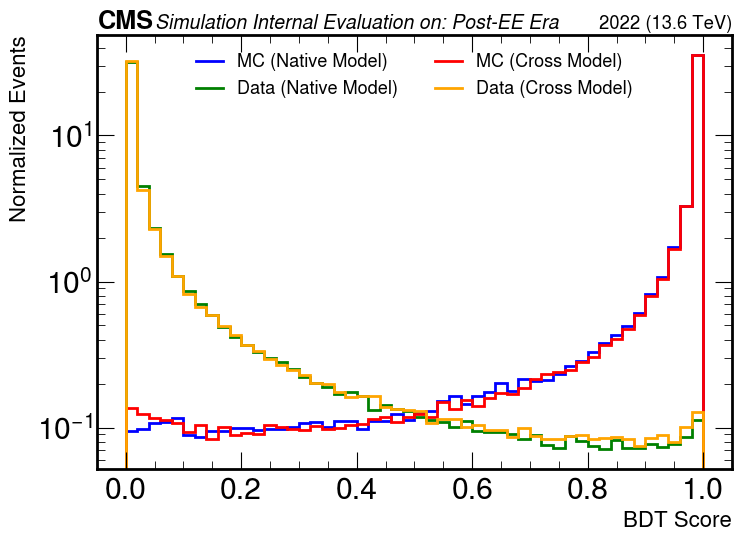

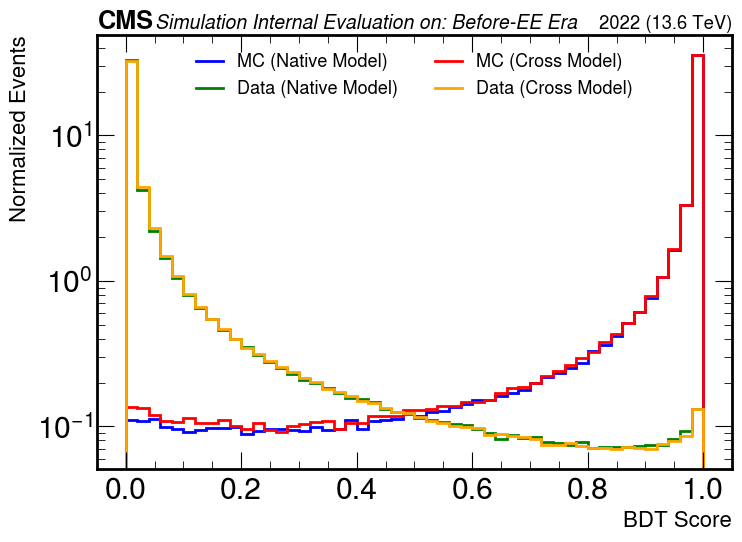

In [25]:
def plot_cross_comparison(df_sig, df_bkg, title, filename):
    plt.figure(figsize=(8, 6))
    
    h_sig_nat, bins = np.histogram(df_sig['score_native'], bins=50, range=(0,1), density=True)
    h_bkg_nat, _    = np.histogram(df_bkg['score_native'], bins=bins, density=True)
    
    h_sig_cro, _    = np.histogram(df_sig['score_cross'], bins=bins, density=True)
    h_bkg_cro, _    = np.histogram(df_bkg['score_cross'], bins=bins, density=True)

    hep.histplot(h_sig_nat, bins, label='MC (Native Model)', color='blue', linewidth=2)
    hep.histplot(h_bkg_nat, bins, label='Data (Native Model)', color='green', linewidth=2)
    hep.histplot(h_sig_cro, bins, label='MC (Cross Model)', color='red', linewidth=2)
    hep.histplot(h_bkg_cro, bins, label='Data (Cross Model)', color='orange', linewidth=2)

    plt.yscale('log')
    plt.xlabel('BDT Score', fontsize=16)
    plt.ylabel('Normalized Events', fontsize=16)
    plt.legend(loc='upper center', ncol=2, fontsize=13)
    
    hep.cms.label(exp="CMS", data=False, year="2022", com=13.6, label=f"Internal\n{title}", fontsize=14)
    
    plt.tight_layout()
    plt.savefig(filename)
    plt.show()

# Comparação nos dados PÓS-EE (Era com o problema do detector)
plot_cross_comparison(df_mc, df_data, "Evaluation on: Post-EE Era", "Comparison_on_PostEE_Dataset.png")
# Comparação nos dados ANTES-EE (Era normal)
plot_cross_comparison(df_mc_EE, df_data_EE, "Evaluation on: Before-EE Era", "Comparison_on_BeforeEE_Dataset.png")